In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ase.io import read
from pathlib import Path


def get_energies(scf_outputs) -> list[list[str, float]]:
    """
    Lê todos os arquivos scf.*.out, extrai a energia por átomo em eV.
    
    Output: [['scf*.out', E/atom (eV)], ...]
    """
    NUM_ATOMOS = 4
  
    files = list( Path(scf_outputs).glob(f'scf*.out') )
    energies = [read(f, format='espresso-out').get_total_energy() / NUM_ATOMOS for f in files]

    data: list[list[str, float]] = [[f.name, e] for f,e in zip(files, energies)]
    # Ordem descrescente de energia.
    data.sort(key=lambda x: x[1], reverse=True)
    return data

def transform_data_to_df(data: list) -> pd.DataFrame:
    """
    Cria um DataFrame com File  E/atom  dE_ref_meV      dE_consec_meV.

    dE_ref_meV: E_min - E_i
    dE_consec_meV : E_{i+1} - E_{i} 
    """
    get_deltaE_consec = lambda x: np.abs(np.r_[0, np.diff(x)])
    get_deltaEref = lambda x: np.abs(x -np.min(x))

    df = pd.DataFrame(data, columns=["File", "E/atom"])
    df['dE_ref_meV'] = get_deltaEref(df['E/atom']) * 1_000
    df['dE_consec_meV'] = get_deltaE_consec(df['E/atom']) * 1_000

    return df
    

def plot_convergence(df: pd.DataFrame, pseudopot_title: str, save: bool = False):
    """
    Args:
        data: DataFrame with columns: File      E/atom  dE_ref_meV      dE_consec_meV
        pseudopot_title: string containing info about selected pseudopotential.
    """

    ecut = np.arange(20,160,10)
    THR = 2.0  # meV

    E_per_atom     = df['E/atom'].to_numpy()
    dE_ref_meV     = df['dE_ref_meV'].to_numpy()
    dE_consec_meV  = df['dE_consec_meV'].to_numpy()

    fig, (axE, axdE) = plt.subplots(
        2, 1,
        sharex=True,
        figsize=(6, 6),
        dpi=300,
        gridspec_kw={'hspace': 0.05}
    )

    # === Painel (a): energia por átomo vs cutoff ===
    axE.set_title(pseudopot_title)
    axE.set_ylabel(r'$E$ (eV/atom)')
    axE.plot(ecut, E_per_atom, marker='s', ls='-', color='black', label=r'$E_i$')
    axE.scatter(ecut[-1], E_per_atom[-1], marker='v', color='black')
    axE.legend()

    # === Painel (b): diferenças em meV/átomo ===

    # Módulo das diferenças
    dE_ref_abs    = np.abs(dE_ref_meV)
    dE_consec_abs = np.abs(dE_consec_meV)

    # Limite superior do eixo y na região de interesse
    YMAX = 10.0  # meV (ajuste se quiser)

    # Versões "clipadas" para plotar
    dE_ref_plot    = np.clip(dE_ref_abs,    0, YMAX)
    dE_consec_plot = np.clip(dE_consec_abs, 0, YMAX)

    axdE.plot(ecut, dE_ref_plot, marker='s', ls='-', label=r'$|E_i - E_{\mathrm{ref}}|$')
    axdE.plot(ecut, dE_consec_plot, marker='o', ls='--', label=r'$|E_i - E_{i-1}|$')

    # Marcar pontos que saturaram (valores reais > YMAX)
    mask_ref_sat    = dE_ref_abs    > YMAX
    mask_consec_sat = dE_consec_abs > YMAX

    axdE.scatter(ecut[mask_ref_sat],
                np.full(mask_ref_sat.sum(), YMAX),
                marker='v', s=40, color='C0')
    axdE.scatter(ecut[mask_consec_sat],
                np.full(mask_consec_sat.sum(), YMAX),
                marker='v', s=40, color='C1')


    # Faixa de tolerância 0–2 meV/átomo
    axdE.axhspan(0.0, THR, alpha=0.15, color='red')

    axdE.set_ylabel(r'$\Delta E$ (meV/atom)')
    axdE.set_xlabel(r'Kinetic energy cutoff (Ry)', labelpad=10)
    axdE.set_ylim(0, YMAX)

    axdE.legend(fontsize=8, loc='upper right')
    if save:
        formats = ["pdf", "png"]
        nome_figura = input("Digite o nome da figura a ser salva:\nEx: minhafigura.{pdf,png}\n")
        formato = nome_figura[-3:]
        if formato not in formats: 
            raise ValueError("Formato não aceito.\n Aceitos: '.pdf', '.png'")
        fig.savefig(nome_figura,format=formato, bbox_inches='tight')
    
    plt.show()


In [2]:
scfs_path =  "./outputs"

data = get_energies(scfs_path)
print(data)

df = transform_data_to_df(data)
display(df)


[['scf_ecutwfc.20.out', -827.1484185639401], ['scf_ecutwfc.30.out', -901.760832625091], ['scf_ecutwfc.40.out', -919.1674586843079], ['scf_ecutwfc.50.out', -920.258581774976], ['scf_ecutwfc.60.out', -920.2684644393826], ['scf_ecutwfc.70.out', -920.2722796454717], ['scf_ecutwfc.80.out', -920.2740582155355], ['scf_ecutwfc.90.out', -920.2757051845438], ['scf_ecutwfc.100.out', -920.2766437732017], ['scf_ecutwfc.110.out', -920.2780116214402], ['scf_ecutwfc.120.out', -920.278627993299], ['scf_ecutwfc.130.out', -920.2789808229052], ['scf_ecutwfc.140.out', -920.2799367248061], ['scf_ecutwfc.150.out', -920.2808206866109]]


,File,E/atom,dE_ref_meV,dE_consec_meV
0,scf_ecutwfc.20.out,-827.148419,93132.402123,0.000000
1,scf_ecutwfc.30.out,-901.760833,18519.988062,74612.414061
2,scf_ecutwfc.40.out,-919.167459,1113.362002,17406.626059
3,scf_ecutwfc.50.out,-920.258582,22.238912,1091.123091
4,scf_ecutwfc.60.out,-920.268464,12.356247,9.882664
5,scf_ecutwfc.70.out,-920.272280,8.541041,3.815206
6,scf_ecutwfc.80.out,-920.274058,6.762471,1.778570
7,scf_ecutwfc.90.out,-920.275705,5.115502,1.646969
8,scf_ecutwfc.100.out,-920.276644,4.176913,0.938589
9,scf_ecutwfc.110.out,-920.278012,2.809065,1.367848


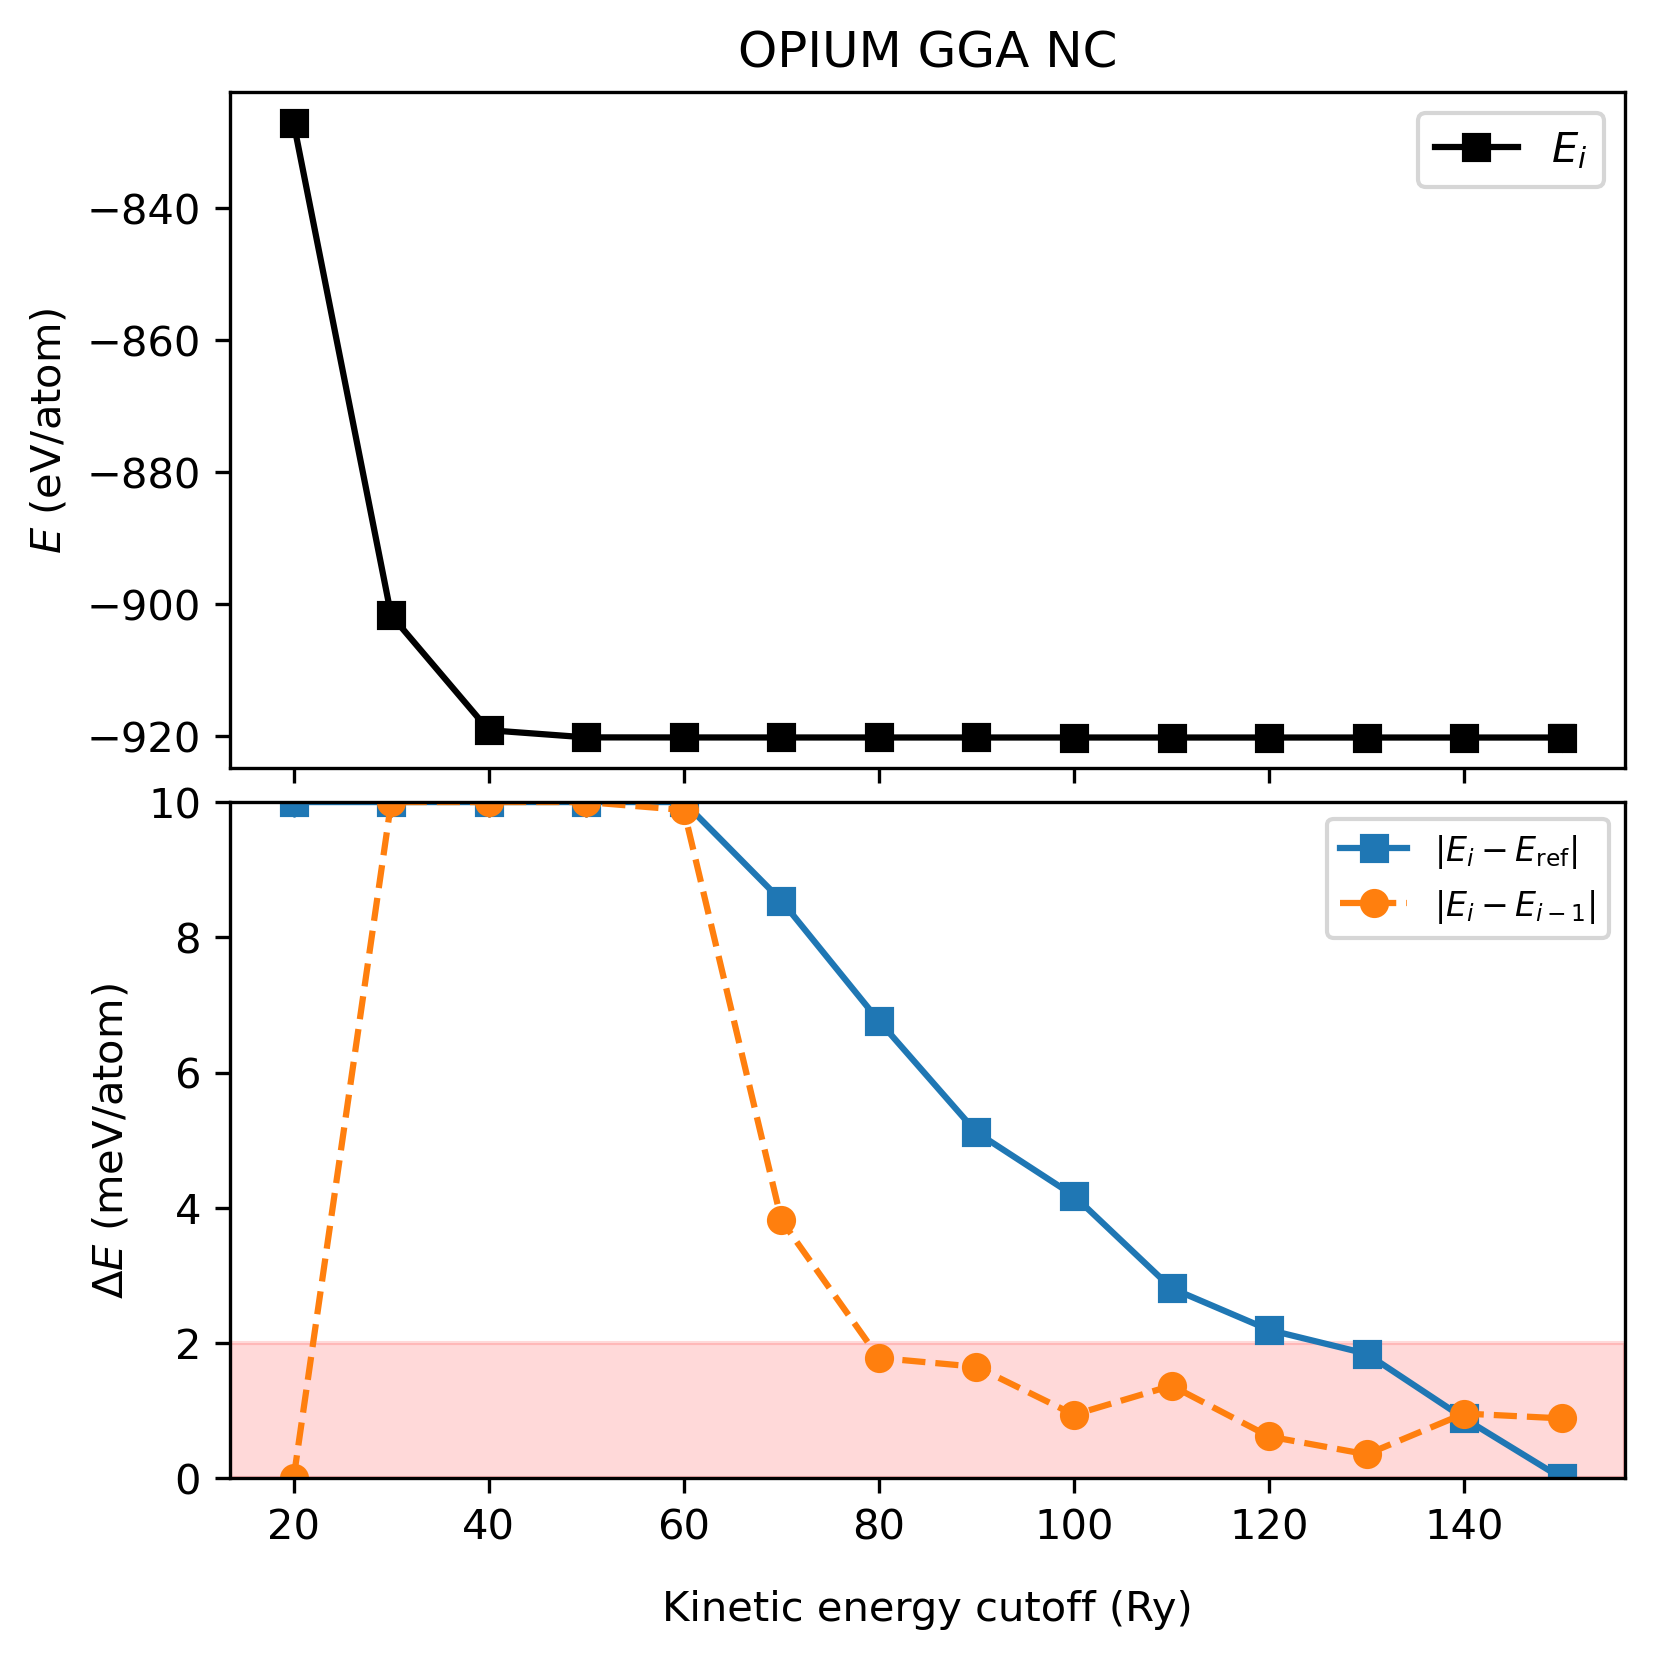

In [3]:
plot_convergence(df, pseudopot_title="OPIUM GGA NC", save = False)